# Burgers — Uniform λ Sampling Ablation

**Experiment:** Compare `mode="uniform"` (each weight ~ U(0,1), no sum-to-1) against the
default `mode="logspace"` (softmax-normalized) on the Burgers equation.

**Motivation:** Advisor idea — decoupling loss weights by sampling independently from [0,1]
removes the implicit competition between terms that softmax/simplex impose.

**Baseline comparison:** `02_burgers.ipynb` has logspace LC-PINN (mean rel-L2 = 0.0009)
and equal-weight baseline (0.1472).

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from pinns.model import LossConditionalPINN
from pinns.training import train_lc_pinn
from pinns.lambda_sampler import LambdaSampler
from pinns.inference import sweep_lambda
from pinns.device import select_device, device_info

from pinns.equations import burgers as eq

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(42)
np.random.seed(42)

HIDDEN_DIMS = [64, 64, 64, 64]
N_STEPS = 200_000
LR = 1e-3
LOG_EVERY = 5_000

Device: mps (Apple GPU)


## 1. Reference solution & training data

In [3]:
print("Computing spectral reference solution...")
ref_snapshots = eq.compute_reference_solution()
batch = eq.generate_training_data(ref_snapshots, device=device)

snap_times = sorted(ref_snapshots.keys())
print(f"Snapshot times: {snap_times}")
print(f"Training data: {', '.join(f'{k}: {v.shape}' for k, v in batch.items())}")

Computing spectral reference solution...
Snapshot times: [0.25, 0.5, 0.75, 1.0]
Training data: coords_pde: torch.Size([2000, 2]), coords_bc: torch.Size([200, 2]), u_bc: torch.Size([200, 1]), coords_ic: torch.Size([200, 2]), u_ic: torch.Size([200, 1]), coords_data: torch.Size([200, 2]), u_data: torch.Size([200, 1])


## 2. Train LC-PINN with uniform sampling

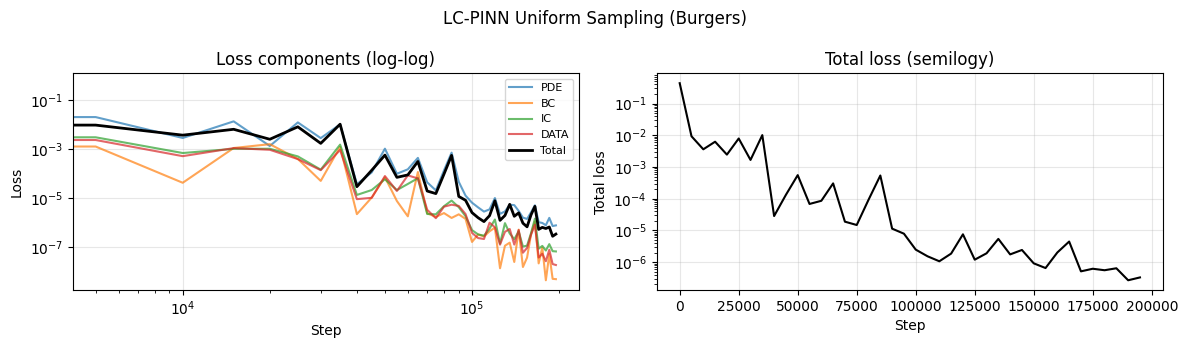

Training: 100%|██████████| 200000/200000 [1:14:52<00:00, 44.52step/s, L=3.30e-07, hw=3.00]



Training complete in 4492s (74.9 min)
Best log(lambda):     [-1.15  -1.217 -0.155 -0.136]
Best softmax(lambda): [0.1353 0.1265 0.3655 0.3728]
Best validation loss: 8.567678e-08

Best lambda (weights): [0.1353 0.1265 0.3655 0.3728]

LC-PINN (uniform) rel-L2 per snapshot: {0.25: 0.00025948917299279344, 0.5: 0.0004548806516504781, 0.75: 0.00023066396048936278, 1.0: 0.0008378716353130553}
Mean: 0.0004


In [4]:
def make_live_plot_callback(title="Training"):
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history["step"]
        ax1.set_title("Loss components (log-log)")
        for key in history:
            if key in ("step", "total", "hw", "elapsed_sec"): continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history["total"], 'k-', lw=2, label="Total")
        ax1.set_xscale("log"); ax1.set_yscale("log")
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
        ax2.set_title("Total loss (semilogy)")
        ax2.semilogy(steps, history["total"], 'k-', lw=1.5)
        ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss"); ax2.grid(True, alpha=0.3)
        fig.tight_layout(); plt.show(); plt.close(fig)
    return on_log

model_uniform = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler_uniform = LambdaSampler(dim=eq.DIM_LAMBDA, device=device, mode="uniform")

history_uniform = train_lc_pinn(
    model_uniform, sampler_uniform, batch, device,
    loss_fn=eq.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=make_live_plot_callback("LC-PINN Uniform Sampling (Burgers)"),
)

best_ll, best_p, _ = sweep_lambda(
    model_uniform, batch, sampler_uniform, device,
    loss_fn=eq.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)
print(f"\nBest lambda (weights): {best_p.cpu().numpy().round(4)}")

torch.save({
    "model_state_dict": model_uniform.state_dict(),
    "best_log_lambda": best_ll,
}, "../checkpoints/burgers_lc_pinn_uniform.pt")

uniform_errors = eq.evaluate(model_uniform, best_ll, ref_snapshots, device)
print(f"\nLC-PINN (uniform) rel-L2 per snapshot: {uniform_errors}")
print(f"Mean: {np.mean(list(uniform_errors.values())):.4f}")

## 3. Comparison with logspace LC-PINN (from 02_burgers.ipynb)

In [5]:
# Load logspace LC-PINN from 02_burgers.ipynb for comparison
model_logspace = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
ckpt = torch.load("../checkpoints/burgers_lc_pinn.pt", map_location=device, weights_only=False)
model_logspace.load_state_dict(ckpt["model_state_dict"])
logspace_ll = ckpt["best_log_lambda"].to(device)

logspace_errors = eq.evaluate(model_logspace, logspace_ll, ref_snapshots, device)
print(f"Logspace LC-PINN rel-L2: {logspace_errors}")
print(f"Logspace mean: {np.mean(list(logspace_errors.values())):.4f}")
print(f"Uniform  mean: {np.mean(list(uniform_errors.values())):.4f}")

Logspace LC-PINN rel-L2: {0.25: 0.00049035582922388, 0.5: 0.0008421330605777573, 0.75: 0.0009707437897184698, 1.0: 0.001361890866437591}
Logspace mean: 0.0009
Uniform  mean: 0.0004


Method                      t=0.25  t=0.50  t=0.75  t=1.00   Mean
-----------------------------------------------------------------
LC-PINN (uniform)           0.0003  0.0005  0.0002  0.0008  0.0004
LC-PINN (logspace)          0.0005  0.0008  0.0010  0.0014  0.0009


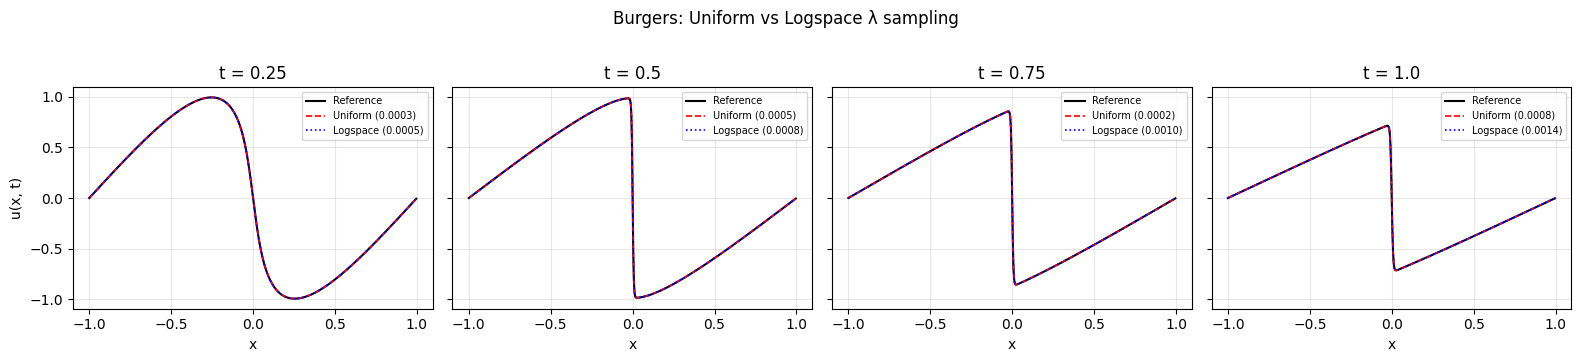

Saved: results/fig_burgers_uniform_vs_logspace.png


In [6]:
# --- Comparison table ---
results = {
    "LC-PINN (uniform)":  uniform_errors,
    "LC-PINN (logspace)": logspace_errors,
}
header = f"{'Method':<26}" + "".join(f"  t={t:.2f}" for t in snap_times) + "   Mean"
print(header)
print("-" * len(header))
for name, errs in results.items():
    vals = [errs[t] for t in snap_times]
    row = f"{name:<26}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}"
    print(row)

# --- Side-by-side prediction plots ---
fig, axes = plt.subplots(1, len(snap_times), figsize=(4 * len(snap_times), 3.5), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, u_ref = ref_snapshots[t_val]
    u_uniform = eq.predict_solution(model_uniform, best_ll, x_ref, t_val, device)
    u_logspace = eq.predict_solution(model_logspace, logspace_ll, x_ref, t_val, device)
    ax.plot(x_ref, u_ref, 'k-', lw=1.5, label='Reference')
    ax.plot(x_ref, u_uniform, 'r--', lw=1.2, label=f'Uniform ({uniform_errors[t_val]:.4f})')
    ax.plot(x_ref, u_logspace, 'b:', lw=1.2, label=f'Logspace ({logspace_errors[t_val]:.4f})')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
axes[0].set_ylabel('u(x, t)')
fig.suptitle('Burgers: Uniform vs Logspace λ sampling', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig_burgers_uniform_vs_logspace.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_burgers_uniform_vs_logspace.png")